In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)

In [2]:
# Convert image to binary
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

In [3]:
# =================================
# Structuring Element
# =================================

kernel = np.ones((3, 3), dtype=np.uint8)

In [4]:
# =================================
# Manual Erosion
# =================================

def erosion(image, kernel):

    result = np.zeros_like(image)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):

            region = image[i-1:i+2, j-1:j+2]

            # All pixels must be white
            if np.all(region[kernel == 1] == 255):
                result[i, j] = 255
            else:
                result[i, j] = 0

    return result


In [5]:

# =================================
# Boundary Extraction
# =================================

eroded = erosion(binary, kernel)

boundary = binary.astype(int) - eroded.astype(int)

boundary = np.clip(boundary, 0, 255).astype(np.uint8)

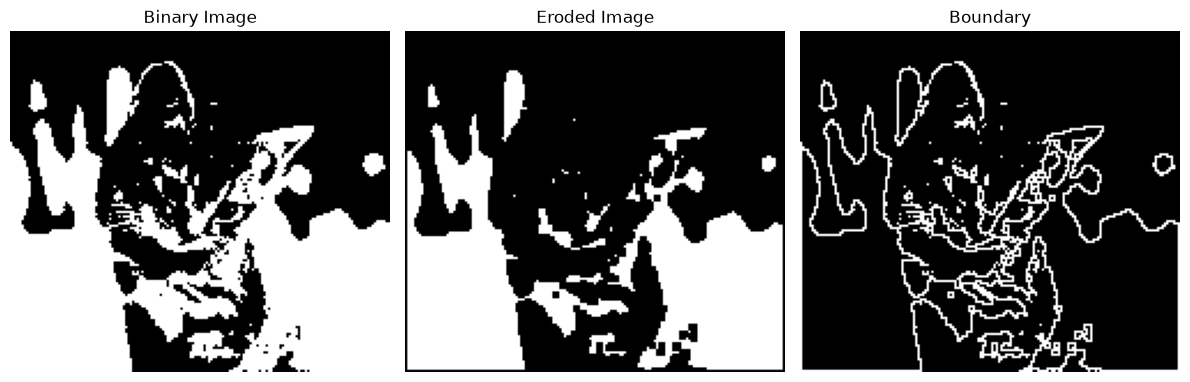

In [6]:
# =================================
# Display Results
# =================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(eroded, cmap="gray")
plt.title("Eroded Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(boundary, cmap="gray")
plt.title("Boundary")
plt.axis("off")

plt.tight_layout()
plt.show()